In [1]:
# import packages
import copy
from datetime import date
import numpy as np
import scipy.sparse as sp

from climada.util.constants import DEF_CRS
from climada.entity import ImpactFuncSet, ImpactFunc
from climada.util.api_client import Client
from climada.engine import ImpactCalc, Impact
import climada.util.yearsets as yearsets
from climada.util.coordinates import country_to_iso

In [2]:
country_name = "Italy"

client = Client()
wind_hazard_set = client.get_hazard(
    "storm_europe", properties={"country_name": country_name}
)


country_assets = client.get_litpop(country=country_name)

impf = ImpactFunc()
impfset = ImpactFuncSet()

impf.intensity = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 100, 160])
impf.mdd = np.array([0, 0, 0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.065, 0.0675, 0.07, 0.071, 0.072, 0.0725, 0.0725])
impf.paa = np.array([0, 0.39346934, 0.632120559, 0.77686984, 0.864664717, 0.917915001, 0.950212932, 0.969802617, 0.981684361, 
                     0.988891003, 0.993262053, 0.995913229, 0.997521248, 0.998496561, 0.999088118, 0.999446916, 0.999664537, 0.9999546, 0.999999887])
impf.haz_type = 'WS'
impf.intensity_unit = "m/s"
impf.id = 1
impfset.append(impf)

# we run the impact calculation for wind:
wind_impact = ImpactCalc(country_assets, impfset, wind_hazard_set).impact()

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


2026-05-05 18:01:10,679 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.078125 degree for 1 coordinates.


Text(0.5, 1.0, 'Occurrence exceedance frequency curve for wind')

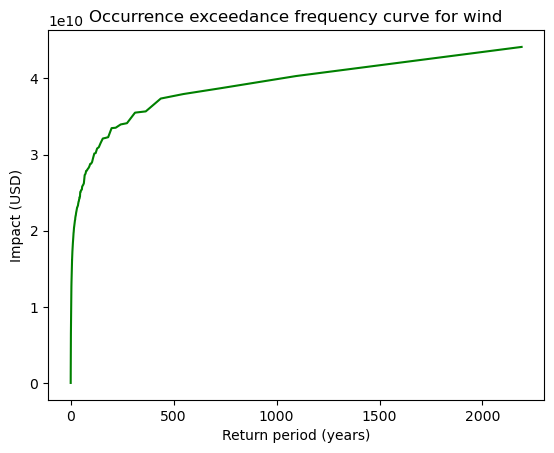

In [3]:
wind_ex_freq = wind_impact.calc_freq_curve()
ax = wind_ex_freq.plot(color="green", label="wind")
ax.set_title("Occurrence exceedance frequency curve for wind")

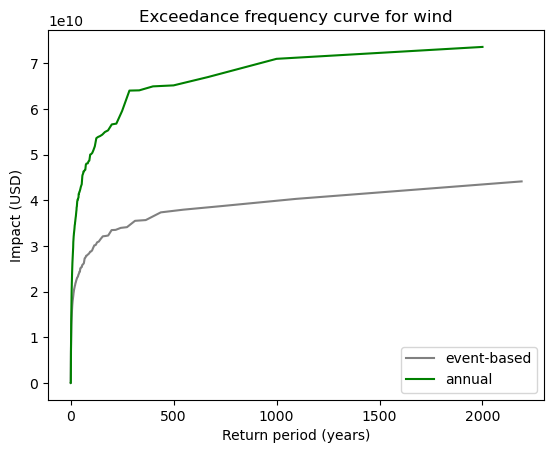

In [4]:
n_sampled_years = 2000
lam = np.sum(wind_impact.frequency)
events_per_year = yearsets.sample_from_poisson(n_sampled_years, lam)
yearset_wind, sampling_vect = yearsets.impact_yearset(
    wind_impact, sampled_years=list(range(1, n_sampled_years + 1)), correction_fac=False
)
sparse_matrix = wind_impact.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sparse_matrix[indices, :].sum(axis=0)
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yearset_wind.imp_mat = summed_matrix

yearset_wind.coord_exp = wind_impact.coord_exp
yearset_wind.at_event, yearset_wind.eai_exp, yearset_wind.aai_agg = (
    ImpactCalc.risk_metrics(yearset_wind.imp_mat, yearset_wind.frequency)
)
wind_ex_freq = wind_impact.calc_freq_curve()
ax = wind_ex_freq.plot(color="gray", label="event-based")
wind_ex_freq_yearset = yearset_wind.calc_freq_curve()
wind_ex_freq_yearset.plot(axis=ax, color="green", label="annual")
ax.set_title("Exceedance frequency curve for wind")
ax.legend();

In [5]:
from exceedance_curve_tools import ExceedanceCurve

fc = ExceedanceCurve(
    values=wind_ex_freq.impact,
    exceedance_frequencies=1/wind_ex_freq.return_per
)

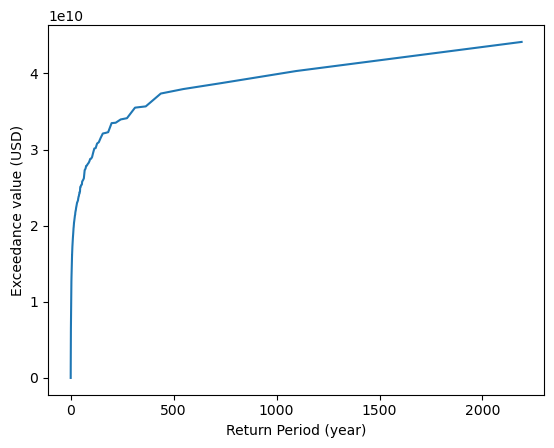

In [6]:
fc.plot_exceedance_curve();

In [7]:
fc_annual = fc.sum_to_aggregation_time_fraction(
    1, 2000
)
fc_monthly = fc.sum_to_aggregation_time_fraction(
    1/12, 2000*12
)

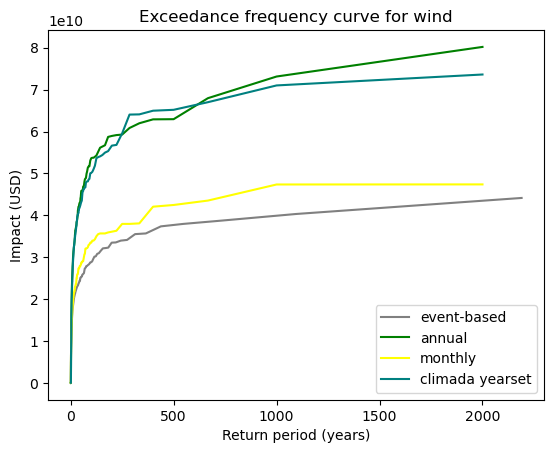

In [8]:
_ , ax = fc.plot_exceedance_curve(color="gray", label="event-based")
fc_annual.plot_exceedance_curve(axis=ax, color="green", label="annual")
fc_monthly.plot_exceedance_curve(axis=ax, color="yellow", label="monthly")
wind_ex_freq_yearset.plot(axis=ax, color="teal", label="climada yearset")
ax.set_title("Exceedance frequency curve for wind")
ax.legend();

In [9]:
for f in [fc, fc_monthly,fc_annual]:
    print(f.average_annual_impact()/1_000_000_000)

11.617294943217729
11.48423509118735
11.862945243275268


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Return Period (year)', ylabel='Exceedance value (USD)'>)

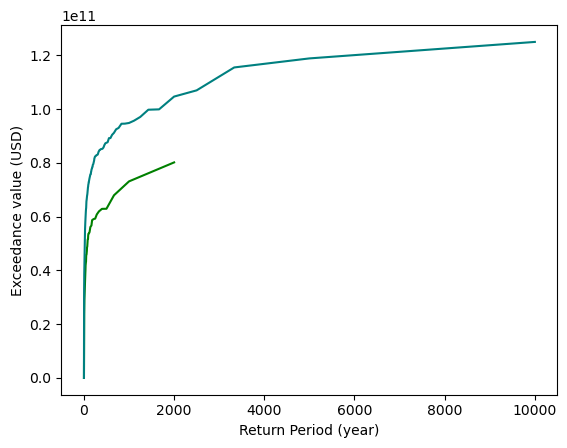

In [32]:
from exceedance_curve_tools import combine_exceedance_curves
fc_comb = combine_exceedance_curves([fc_annual, fc], coincidence_fraction=None)

_ , ax = fc_annual.plot_exceedance_curve(color="green", label="annual")
fc_comb.plot_exceedance_curve(axis=ax, color="teal", label="combined")
